In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FOLDER = r"D:\Guvi\Projects\Stock-Analytics\Stock_Trial_CSV"
OUTPUT_FOLDER = r"D:\Guvi\Projects\Stock-Analytics\analysis_outputs"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [55]:
all_stocks = []

for file in os.listdir(INPUT_FOLDER):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(INPUT_FOLDER, file))
        df["Ticker"] = file.replace(".csv", "")
        df["date"] = pd.to_datetime(df["date"])
        all_stocks.append(df)

master_df = pd.concat(all_stocks, ignore_index=True)

In [56]:
master_df

,Ticker,close,date,high,low,month,open,volume
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224
...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304


In [57]:
master_df.isnull().sum()

Ticker    0
close     0
date      0
high      0
low       0
month     0
open      0
volume    0
dtype: int64

In [58]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14200 entries, 0 to 14199
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Ticker  14200 non-null  object        
 1   close   14200 non-null  float64       
 2   date    14200 non-null  datetime64[ns]
 3   high    14200 non-null  float64       
 4   low     14200 non-null  float64       
 5   month   14200 non-null  object        
 6   open    14200 non-null  float64       
 7   volume  14200 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 887.6+ KB


In [59]:
master_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14195    False
14196    False
14197    False
14198    False
14199    False
Length: 14200, dtype: bool

In [60]:
#daily returns
master_df = master_df.sort_values(["Ticker", "date"])
master_df["daily_return"] = master_df.groupby("Ticker")["close"].pct_change()

In [61]:
master_df

,Ticker,close,date,high,low,month,open,volume,daily_return
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899,NaN
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377,0.032548
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455,0.000568
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035,0.004764
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224,-0.014325
...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760,-0.004042
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882,-0.024440
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889,0.016551
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304,-0.008630


In [62]:
#0
#Yearly return calculation
yearly_return = (
    master_df.groupby("Ticker")
    .apply(lambda x: (x.iloc[-1]["close"] - x.iloc[0]["close"]) / x.iloc[0]["close"])
    .reset_index(name="yearly_return")
)

C:\Users\Prabhu\AppData\Local\Temp\ipykernel_12836\3423532627.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x.iloc[-1]["close"] - x.iloc[0]["close"]) / x.iloc[0]["close"])


In [63]:
#top 10 green stocks
top_10_green = yearly_return.sort_values("yearly_return", ascending=False).head(10)
top_10_green.to_csv(os.path.join(OUTPUT_FOLDER, "top_10_green.csv"), index=False)

In [64]:
#top 10 loss stocks
top_10_loss = yearly_return.sort_values("yearly_return").head(10)
top_10_loss.to_csv(os.path.join(OUTPUT_FOLDER, "top_10_loss.csv"), index=False)

In [65]:
#Market summary
market_summary = {
    "green_stocks": (yearly_return["yearly_return"] > 0).sum(),
    "red_stocks": (yearly_return["yearly_return"] <= 0).sum(),
    "average_price": master_df["close"].mean(),
    "average_volume": master_df["volume"].mean()
}

market_summary_df = pd.DataFrame([market_summary])
market_summary_df.to_csv(os.path.join(OUTPUT_FOLDER, "market_summary.csv"), index=False)

In [66]:
#1.Volatility Analysis
volatility_df = (
    master_df.groupby("Ticker")["daily_return"]
    .std()
    .reset_index(name="volatility")
)

In [67]:
volatility_df.to_csv(os.path.join(OUTPUT_FOLDER, "volatility.csv"), index=False)

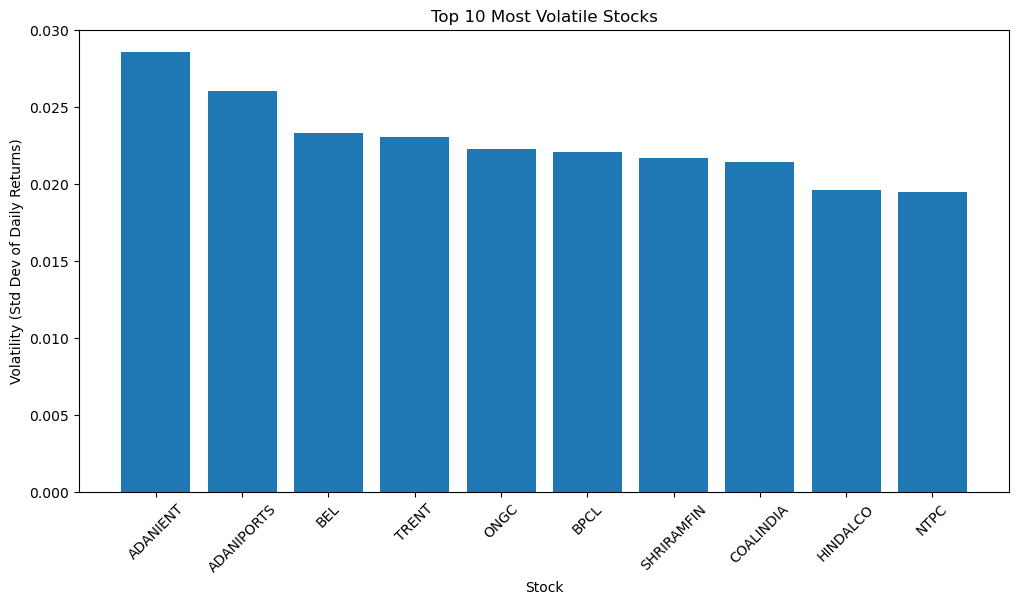

In [68]:
top_10_volatile = volatility_df.sort_values("volatility", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_10_volatile["Ticker"], top_10_volatile["volatility"])
plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Stock")
plt.ylabel("Volatility (Std Dev of Daily Returns)")
plt.xticks(rotation=45)
plt.show()

In [69]:
#2. Cumulative return
master_df["cumulative_return"] = (
    master_df.groupby("Ticker")["daily_return"]
    .transform(lambda x: (1 + x).cumprod())
)

In [70]:
#top 5 performer
top_5 = (
    master_df.groupby("Ticker")
    .tail(1)
    .sort_values("cumulative_return", ascending=False)
    .head(5)["Ticker"]
)

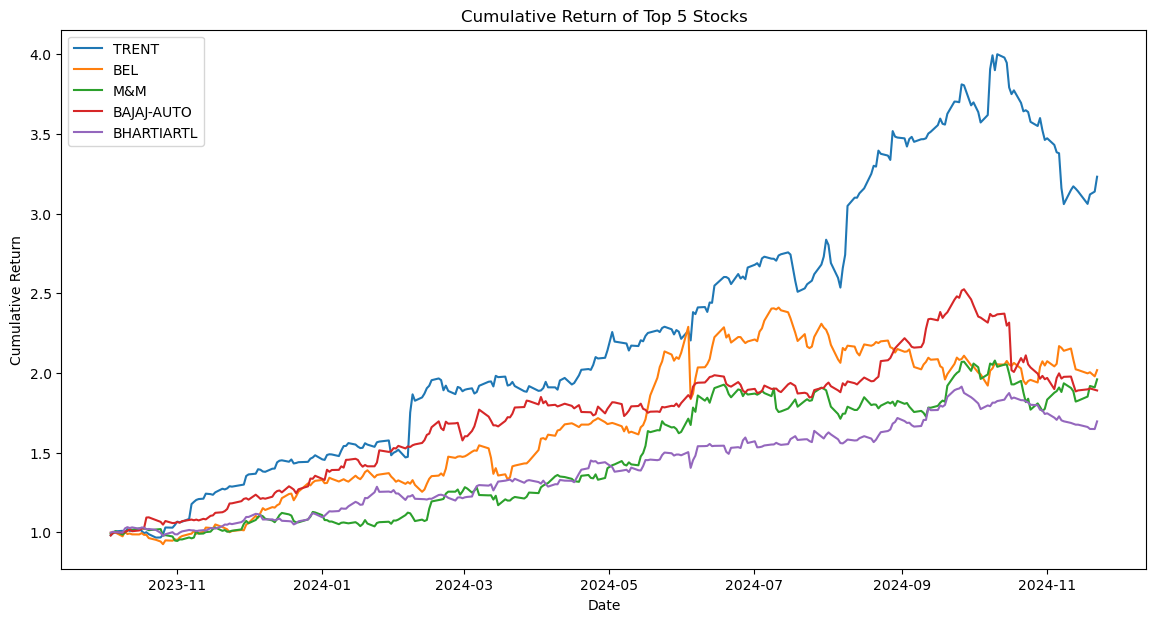

In [71]:
plt.figure(figsize=(14,7))

for ticker in top_5:
    df = master_df[master_df["Ticker"] == ticker]
    plt.plot(df["date"], df["cumulative_return"], label=ticker)

plt.legend()
plt.title("Cumulative Return of Top 5 Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

In [72]:
# Safety: flatten index if any
if isinstance(master_df.index, pd.MultiIndex) or master_df.index.name is not None:
    master_df = master_df.reset_index()

# Ensure correct column names
master_df.columns = master_df.columns.str.strip()

# Ensure date is datetime
master_df["date"] = pd.to_datetime(master_df["date"])

In [73]:
import os

OUTPUT_FOLDER = r"D:\Guvi\Projects\Stock-Analytics\analysis_outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Filter only top 5 tickers
cumulative_return_df = master_df[
    master_df["Ticker"].isin(top_5)
][["date", "Ticker", "cumulative_return"]].copy()

# Sort for readability
cumulative_return_df = cumulative_return_df.sort_values(
    ["Ticker", "date"]
)

# Save to CSV
csv_path = os.path.join(
    OUTPUT_FOLDER, "top_5_cumulative_return.csv"
)

cumulative_return_df.to_csv(csv_path, index=False)

print("✅ top_5_cumulative_return.csv created successfully")

✅ top_5_cumulative_return.csv created successfully


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

sector_df = pd.read_csv("sector_data.csv")

# safety: column names lowercase
sector_df.columns = sector_df.columns.str.lower()

In [75]:
master_df.columns = master_df.columns.str.lower()

master_df["date"] = pd.to_datetime(master_df["date"])

In [76]:
master_df

,ticker,close,date,high,low,month,open,volume,daily_return,cumulative_return
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899,NaN,NaN
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377,0.032548,1.032548
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455,0.000568,1.033134
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035,0.004764,1.038056
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224,-0.014325,1.023186
...,...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760,-0.004042,1.397706
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882,-0.024440,1.363547
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889,0.016551,1.386114
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304,-0.008630,1.374152


In [77]:
master_df.ticker

0        ADANIENT
1        ADANIENT
2        ADANIENT
3        ADANIENT
4        ADANIENT
           ...   
14195       WIPRO
14196       WIPRO
14197       WIPRO
14198       WIPRO
14199       WIPRO
Name: ticker, Length: 14200, dtype: object

In [78]:
sector_df = sector_df.rename(columns={"symbol": "ticker"})

In [79]:
sector_df

,company,sector,ticker
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK
5,BAJAJ AUTO,AUTOMOBILES,BAJAJ AUTO: BAJAJ-AUTO
6,BAJAJ FINANCE,FINANCE,BAJAJ FINANCE: BAJFINANCE
7,BAJAJ FINSERV,FINANCE,BAJAJ FINSERV: BAJAJFINSV
8,BHARAT ELECTRONICS,DEFENCE,BHARAT ELECTRONICS: BEL
9,BHARTI AIRTEL,TELECOM,BHARTI AIRTEL: AIRTEL


In [80]:
print(sector_df.columns.tolist())

['company', 'sector', 'ticker']


In [81]:
import pandas as pd
import os

STOCK_FOLDER = "D:\Guvi\Projects\Stock-Analytics\Stock_Trial_CSV"

dfs = []

for file in os.listdir(STOCK_FOLDER):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(STOCK_FOLDER, file))
        dfs.append(df)

m_df = pd.concat(dfs, ignore_index=True)

In [82]:
m_df

,Ticker,close,date,high,low,month,open,volume
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224
...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304


In [83]:
import pandas as pd

sector_df = pd.read_csv("D:\Guvi\Projects\Stock-Analytics\Sector_data.csv")

In [84]:
sector_df

,COMPANY,sector,Symbol
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK
5,BAJAJ AUTO,AUTOMOBILES,BAJAJ AUTO: BAJAJ-AUTO
6,BAJAJ FINANCE,FINANCE,BAJAJ FINANCE: BAJFINANCE
7,BAJAJ FINSERV,FINANCE,BAJAJ FINSERV: BAJAJFINSV
8,BHARAT ELECTRONICS,DEFENCE,BHARAT ELECTRONICS: BEL
9,BHARTI AIRTEL,TELECOM,BHARTI AIRTEL: AIRTEL


In [104]:
sector_df["company_extracted"] = (
    sector_df["Symbol"]
    .astype(str)
    .str.split(":")
    .str[0]
    .str.strip()
)

In [105]:
sector_df

,COMPANY,sector,Symbol,Ticker,company_extracted
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN,ADANIGREEN,ADANI ENTERPRISES
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS,ADANIPORTS,ADANI PORTS & SEZ
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP,APOLLOHOSP,APOLLO HOSPITALS
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT,ASIANPAINT,ASIAN PAINTS
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK,AXISBANK,AXIS BANK
5,BAJAJ AUTO,AUTOMOBILES,BAJAJ AUTO: BAJAJ-AUTO,BAJAJ-AUTO,BAJAJ AUTO
6,BAJAJ FINANCE,FINANCE,BAJAJ FINANCE: BAJFINANCE,BAJFINANCE,BAJAJ FINANCE
7,BAJAJ FINSERV,FINANCE,BAJAJ FINSERV: BAJAJFINSV,BAJAJFINSV,BAJAJ FINSERV
8,BHARAT ELECTRONICS,DEFENCE,BHARAT ELECTRONICS: BEL,BEL,BHARAT ELECTRONICS
9,BHARTI AIRTEL,TELECOM,BHARTI AIRTEL: AIRTEL,AIRTEL,BHARTI AIRTEL


In [106]:
# Extract company name from Symbol
sector_df["company_extracted"] = (
    sector_df["Symbol"]
    .astype(str)
    .str.split(":")
    .str[0]
    .str.strip()
)

# Keep only what we need
sector_clean = sector_df[["company_extracted", "sector"]]

In [107]:
sector_clean

,company_extracted,sector
0,ADANI ENTERPRISES,MISCELLANEOUS
1,ADANI PORTS & SEZ,MISCELLANEOUS
2,APOLLO HOSPITALS,MISCELLANEOUS
3,ASIAN PAINTS,PAINTS
4,AXIS BANK,BANKING
5,BAJAJ AUTO,AUTOMOBILES
6,BAJAJ FINANCE,FINANCE
7,BAJAJ FINSERV,FINANCE
8,BHARAT ELECTRONICS,DEFENCE
9,BHARTI AIRTEL,TELECOM


In [108]:
m_df["Ticker"] = m_df["Ticker"].str.strip()

sector_new = m_df.merge(
    sector_clean,
    left_on="Ticker",
    right_on="company_extracted",
    how="left"
)

In [109]:
m_df

,Ticker,close,date,high,low,month,open,volume
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224
...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304


In [110]:
sector_new = sector_new.sort_values(["Ticker", "date"])

sector_new["daily_return"] = (
    sector_new.groupby("Ticker")["close"].pct_change()
)

In [111]:
sector_new

,Ticker,close,date,high,low,month,open,volume,company_extracted,sector,daily_return
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899,NaN,NaN,NaN
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377,NaN,NaN,0.032548
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455,NaN,NaN,0.000568
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035,NaN,NaN,0.004764
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224,NaN,NaN,-0.014325
...,...,...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760,WIPRO,SOFTWARE,-0.004042
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882,WIPRO,SOFTWARE,-0.024440
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889,WIPRO,SOFTWARE,0.016551
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304,WIPRO,SOFTWARE,-0.008630


In [130]:
sector_new["company_extracted"].isna().sum()

np.int64(10792)

In [114]:
sector_new["date"] = pd.to_datetime(sector_new["date"], errors="coerce")

In [115]:
sector_new["year"] = sector_new["date"].dt.year

In [116]:
sector_new = sector_new.sort_values(["Ticker", "date"])

sector_new["daily_return"] = (
    sector_new.groupby("Ticker")["close"].pct_change()
)

In [117]:
sector_new 

,Ticker,close,date,high,low,month,open,volume,company_extracted,sector,daily_return,year
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899,NaN,NaN,NaN,2023
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377,NaN,NaN,0.032548,2023
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455,NaN,NaN,0.000568,2023
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035,NaN,NaN,0.004764,2023
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224,NaN,NaN,-0.014325,2023
...,...,...,...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760,WIPRO,SOFTWARE,-0.004042,2024
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882,WIPRO,SOFTWARE,-0.024440,2024
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889,WIPRO,SOFTWARE,0.016551,2024
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304,WIPRO,SOFTWARE,-0.008630,2024


In [118]:
yearly_return = (
    sector_new
    .groupby(["sector", "Ticker", "year"])["daily_return"]
    .mean()
    .reset_index()
)

In [119]:
sector_yearly_avg = (
    yearly_return
    .groupby("sector")["daily_return"]
    .mean()
    .reset_index()
    .rename(columns={"daily_return": "avg_yearly_return"})
)

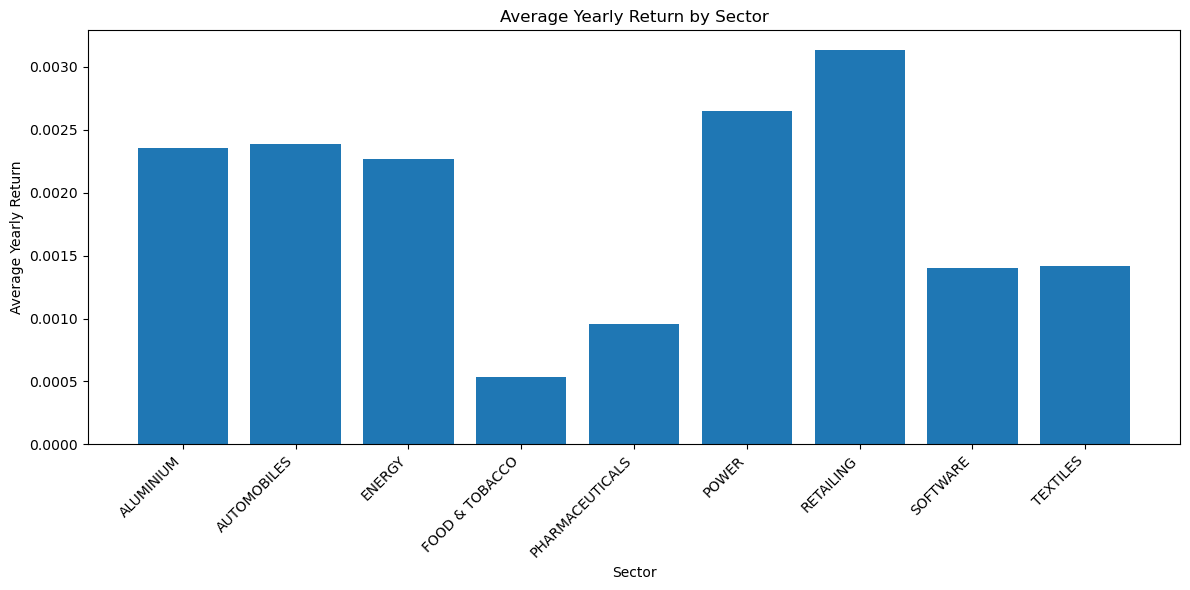

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(
    sector_yearly_avg["sector"],
    sector_yearly_avg["avg_yearly_return"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Average Yearly Return")
plt.title("Average Yearly Return by Sector")

plt.tight_layout()
plt.show()

In [122]:
sector_yearly_avg.to_csv(
    r"D:\Guvi\Projects\Stock-Analytics\analysis_outputs\average_yearly_return_by_sector.csv",
    index=False
)

In [124]:
#4.Stock Price Correlation
pivot_close = m_df.pivot(index="date", columns="Ticker", values="close")

correlation_matrix = pivot_close.corr()

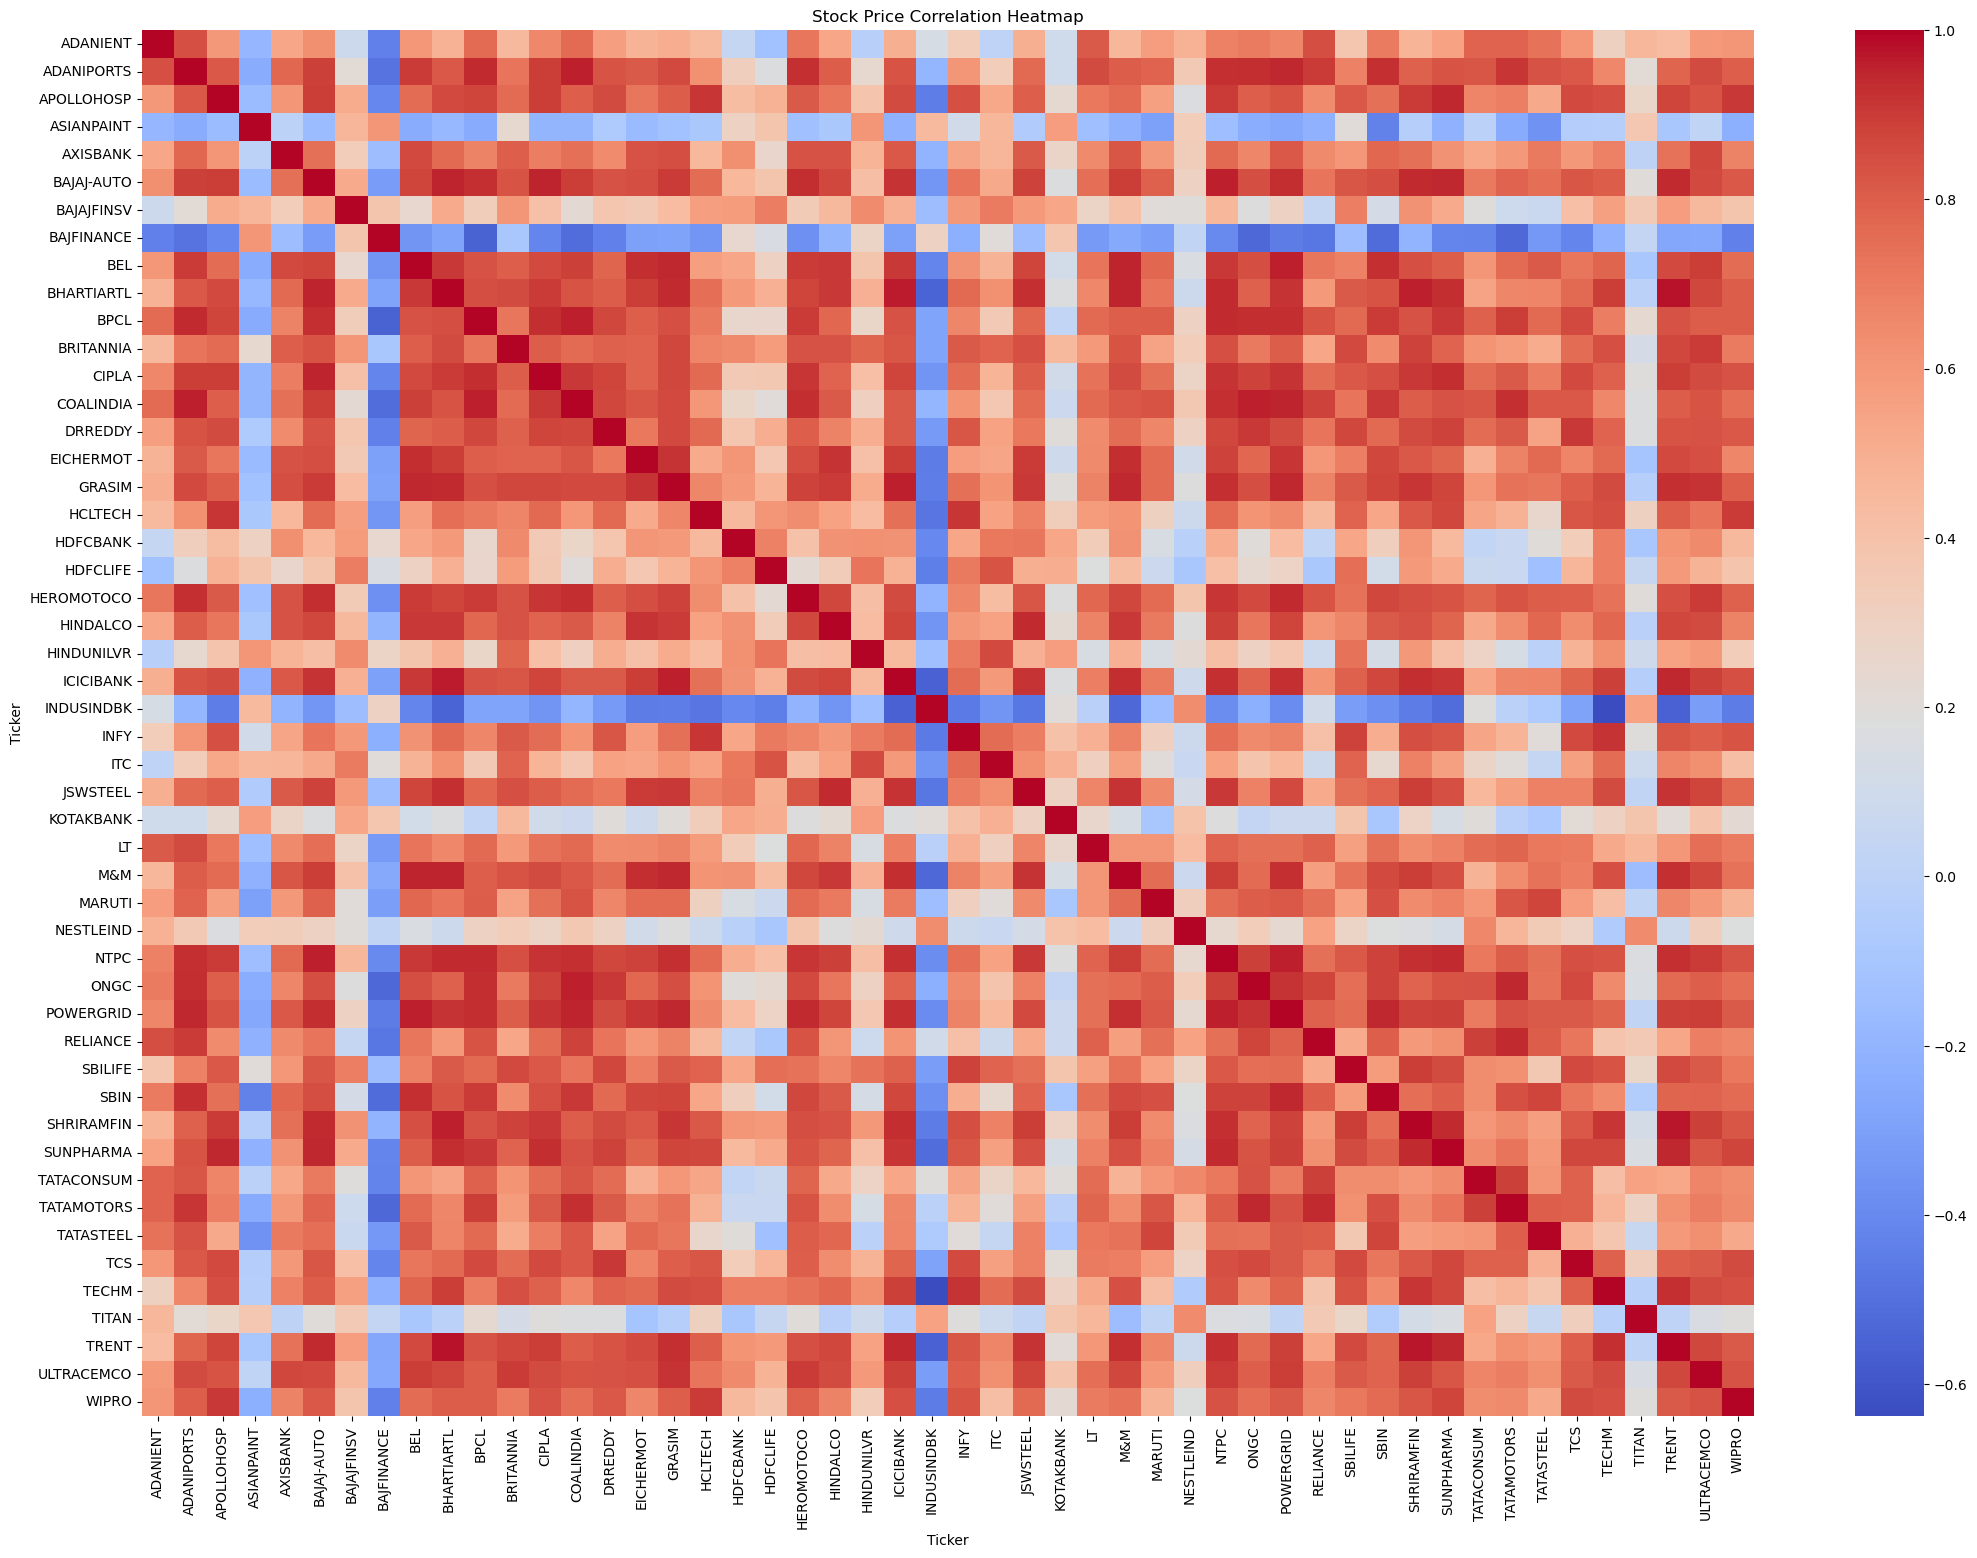

In [ ]:
plt.figure(figsize=(26,18))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.title("Stock Price Correlation Heatmap")
plt.show()

In [ ]:
correlation_csv_path = os.path.join(
    OUTPUT_FOLDER,
    "stock_price_correlation.csv"
)

correlation_matrix.to_csv(correlation_csv_path)

print("✅ stock_price_correlation.csv saved successfully")

✅ stock_price_correlation.csv saved successfully


In [126]:
import pandas as pd

m_df["date"] = pd.to_datetime(m_df["date"])

In [127]:
#5.Month wise top 5 gainers and losers
m_df["month"] = m_df["date"].dt.to_period("M")

monthly_return = (
    m_df.groupby(["Ticker", "month"])
    .apply(lambda x: (x.iloc[-1]["close"] - x.iloc[0]["close"]) / x.iloc[0]["close"])
    .reset_index(name="monthly_return")
)

C:\Users\Prabhu\AppData\Local\Temp\ipykernel_12836\557981240.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x.iloc[-1]["close"] - x.iloc[0]["close"]) / x.iloc[0]["close"])


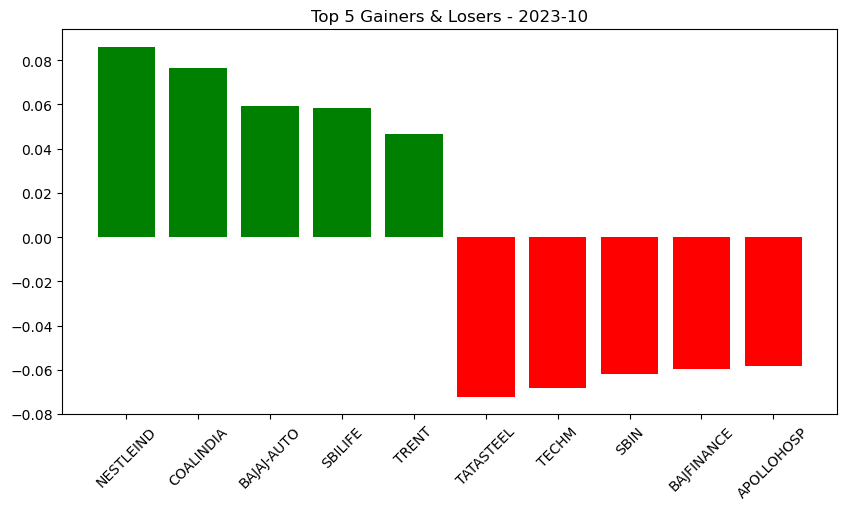

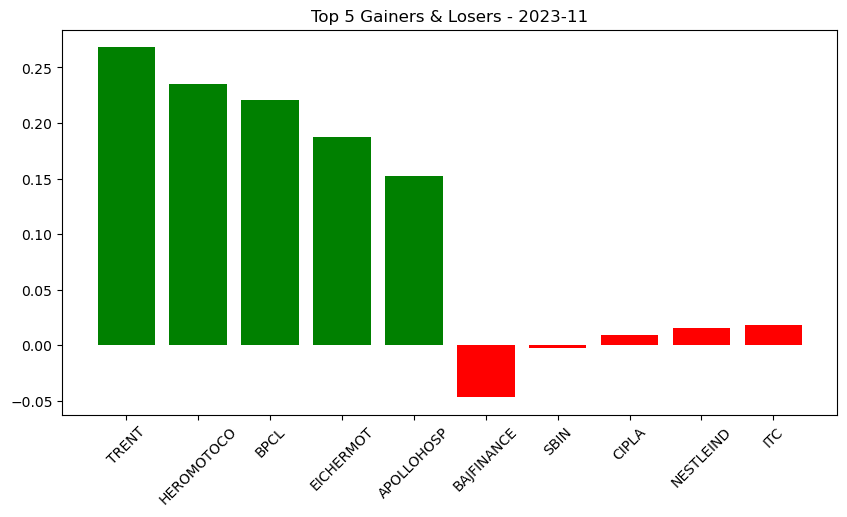

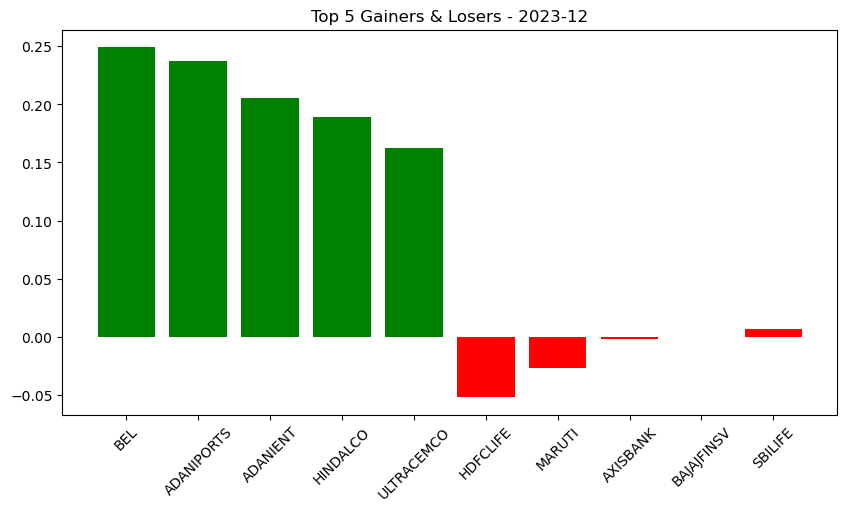

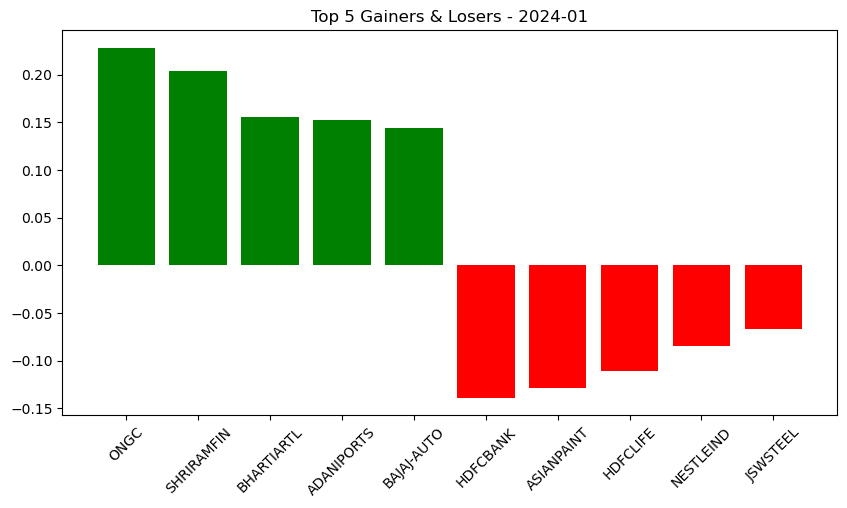

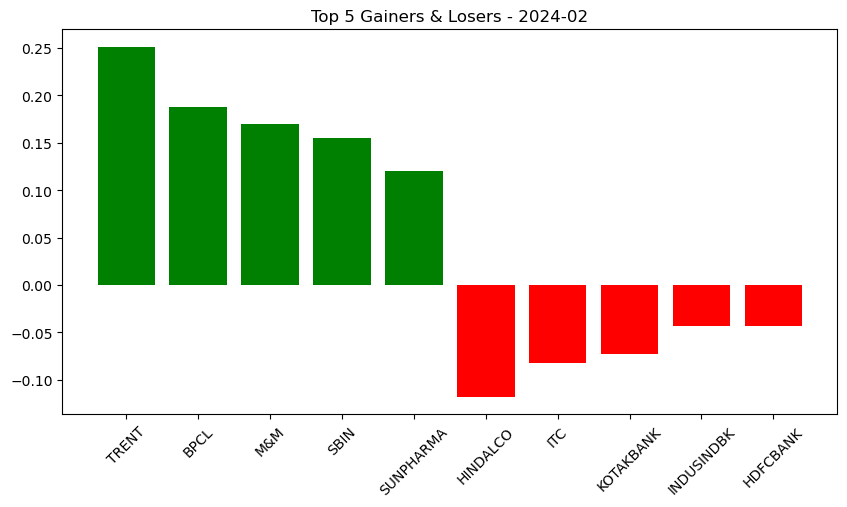

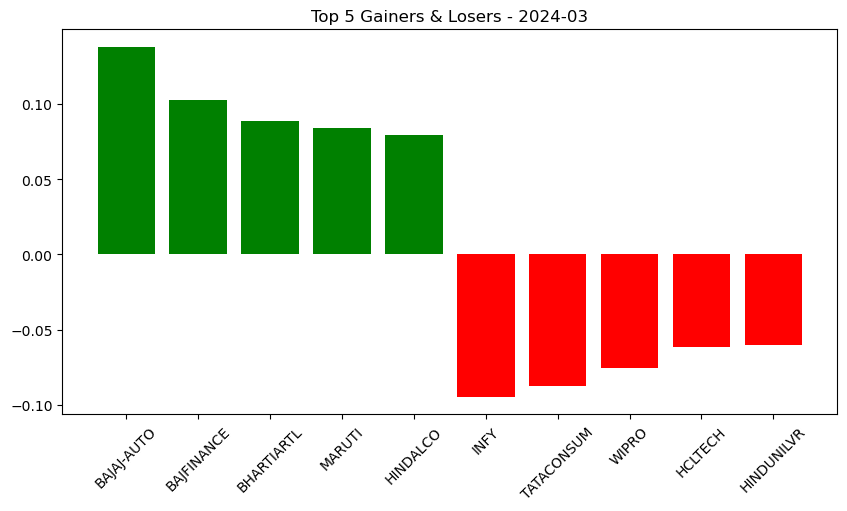

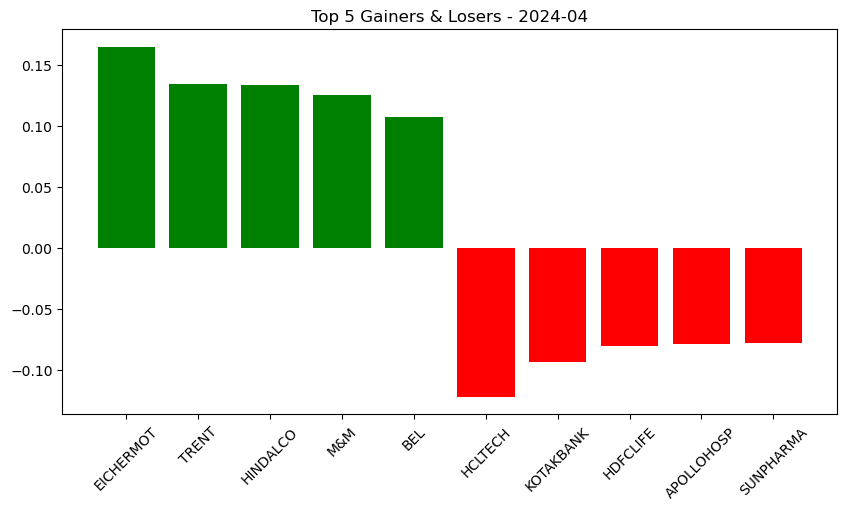

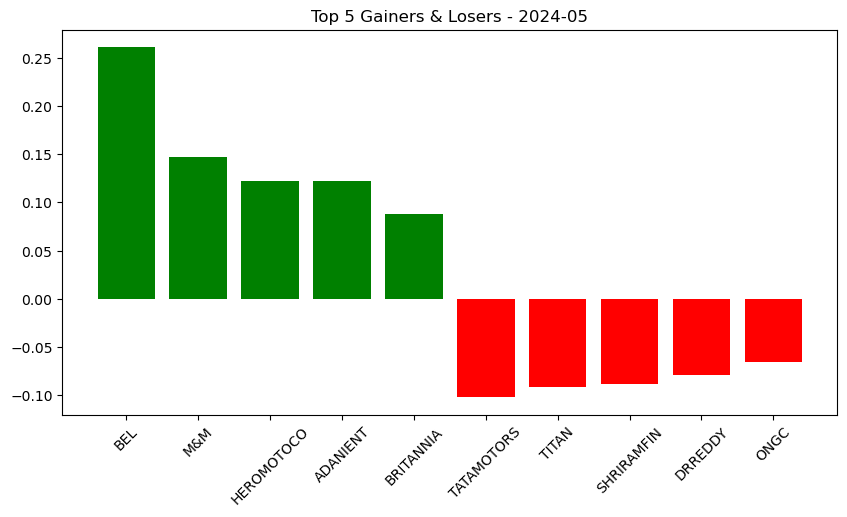

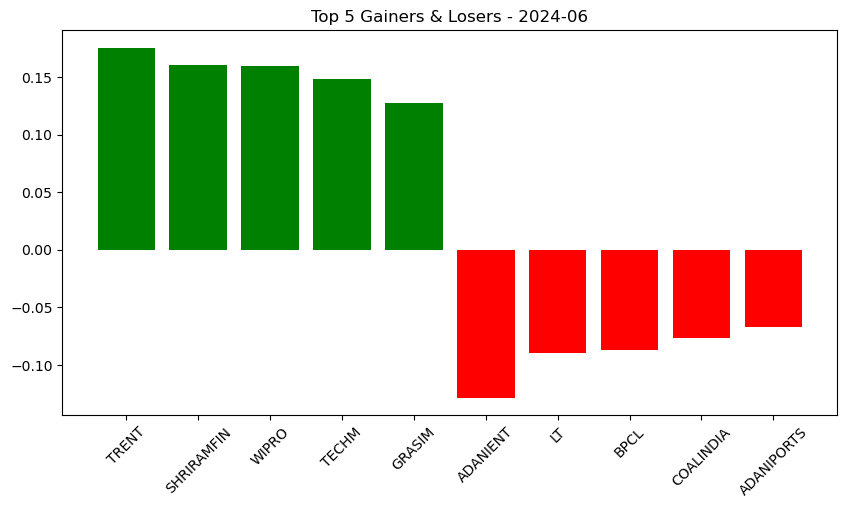

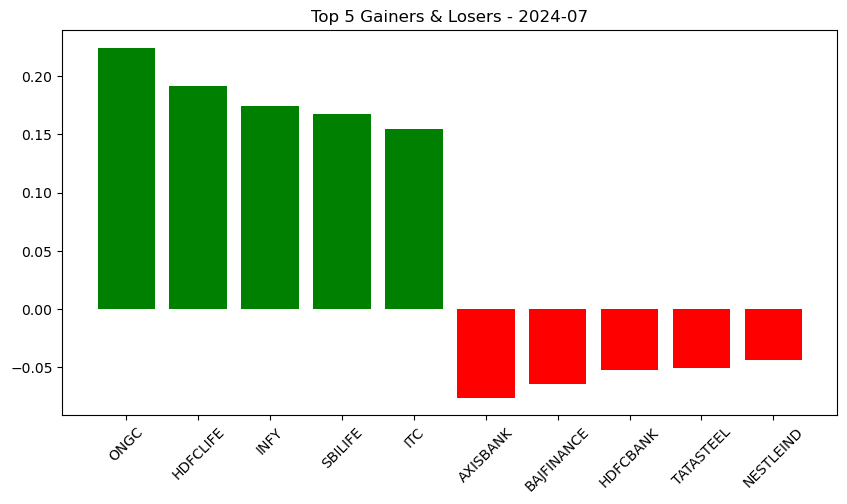

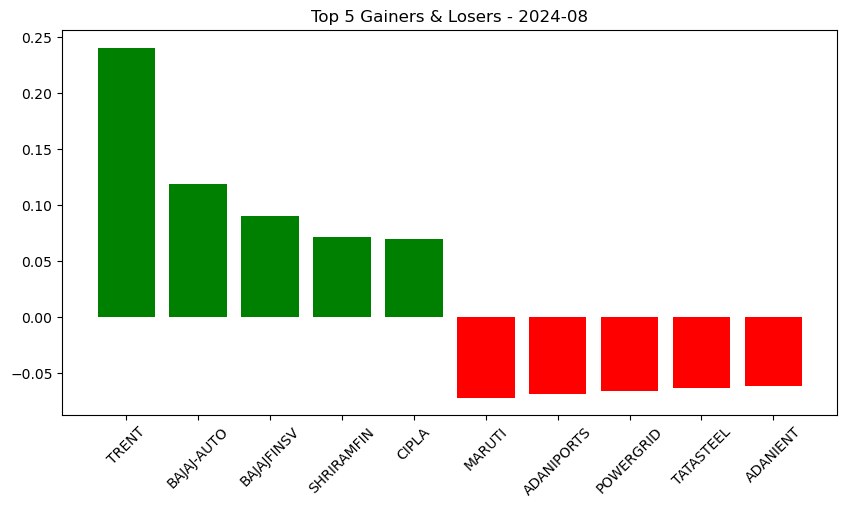

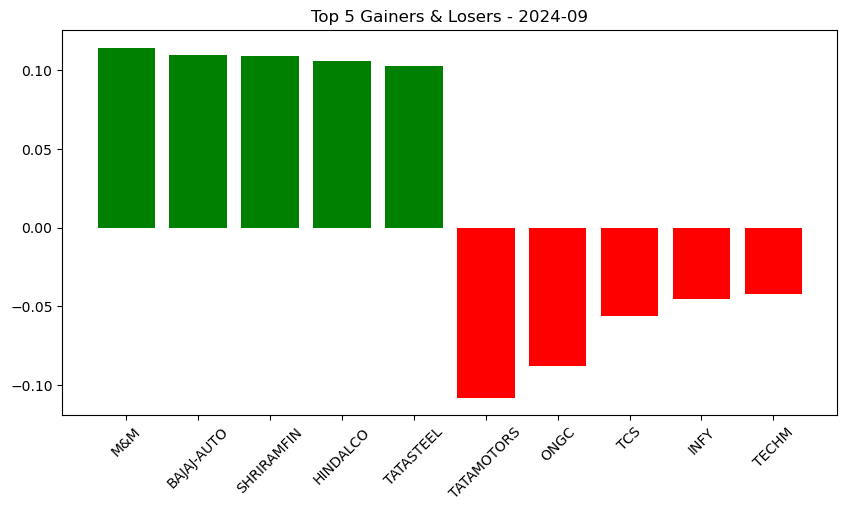

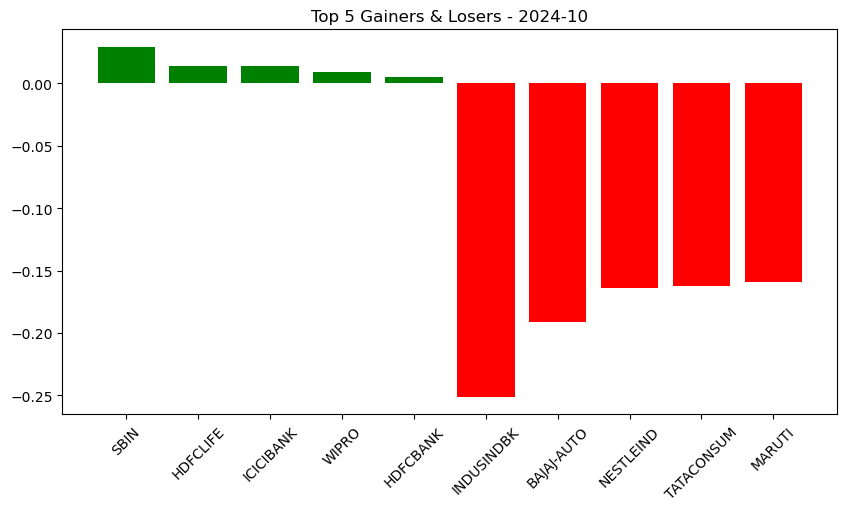

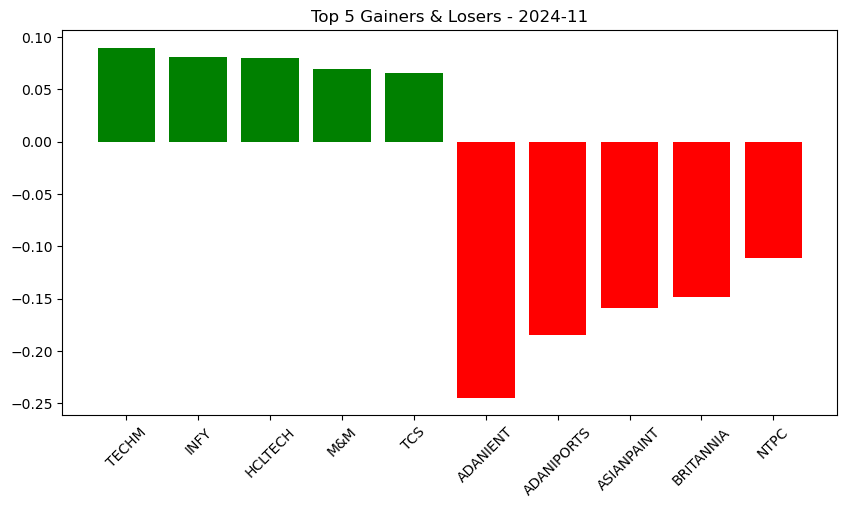

In [128]:
for month in monthly_return["month"].unique():
    df_month = monthly_return[monthly_return["month"] == month]

    top_gainers = df_month.sort_values("monthly_return", ascending=False).head(5)
    top_losers = df_month.sort_values("monthly_return").head(5)

    plt.figure(figsize=(10,5))
    plt.bar(top_gainers["Ticker"], top_gainers["monthly_return"], color="green")
    plt.bar(top_losers["Ticker"], top_losers["monthly_return"], color="red")
    plt.title(f"Top 5 Gainers & Losers - {month}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
master_df

,Ticker,close,date,high,low,month,open,volume,daily_return,cumulative_return
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,2023-10,2418.00,2019899,NaN,NaN
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,2023-10,2402.20,2857377,0.032548,1.032548
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,2023-10,2477.95,1132455,0.000568,1.033134
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,2023-10,2466.35,1510035,0.004764,1.038056
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,2023-10,2440.00,1408224,-0.014325,1.023186
...,...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14 05:30:00,574.55,564.20,2024-11,568.95,4891760,-0.004042,1.397706
14196,WIPRO,552.85,2024-11-18 05:30:00,566.70,540.30,2024-11,566.70,7644882,-0.024440,1.363547
14197,WIPRO,562.00,2024-11-19 05:30:00,569.80,554.70,2024-11,556.00,6459889,0.016551,1.386114
14198,WIPRO,557.15,2024-11-21 05:30:00,567.60,555.30,2024-11,562.00,5836304,-0.008630,1.374152


In [ ]:
import os

records = []

for month in monthly_return["month"].unique():
    df_month = monthly_return[monthly_return["month"] == month]

    top_gainers = (
        df_month.sort_values("monthly_return", ascending=False)
        .head(5)
        .assign(type="Gainer")
    )

    top_losers = (
        df_month.sort_values("monthly_return")
        .head(5)
        .assign(type="Loser")
    )

    records.append(top_gainers)
    records.append(top_losers)

final_monthly_top5 = pd.concat(records)

# Convert Period to string for CSV
final_monthly_top5["month"] = final_monthly_top5["month"].astype(str)

# Save CSV
csv_path = os.path.join(
    OUTPUT_FOLDER,
    "monthwise_top_5_gainers_losers.csv"
)

final_monthly_top5.to_csv(csv_path, index=False)

print("✅ monthwise_top_5_gainers_losers.csv created successfully")

✅ monthwise_top_5_gainers_losers.csv created successfully
